# Story A: Taste Tribes — User Segmentation via Clustering

**Module:** Story A | **Methods:** Balanced K-Means, GMM, t-SNE, PCA  
**Author:** Vĩnh Hoàng

Mục tiêu của notebook này là phân nhóm người dùng MovieLens thành các **Taste Tribes** dựa trên hành vi xem phim và sở thích thể loại.

Pipeline:
1. Load dữ liệu
2. Preprocessing theo 2 nhóm feature: **magnitude** và **genre preference**
3. Tìm K tối ưu bằng K sweep
4. Train K-Means
5. Gán tên cluster và trực quan hóa
6. So sánh với GMM
7. Xuất artifact phục vụ report / demo

In [19]:
import os
import json
import math
import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Plotly renderer for VS Code / Jupyter
pio.renderers.default = "vscode"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "data-warehousing"
STORY_DIR = os.path.join("artifacts", "story_A")
TABLES_OUT = os.path.join(STORY_DIR, "tables")
REPORTS_OUT = os.path.join(STORY_DIR, "reports")
FIGURES_OUT = os.path.join(STORY_DIR, "figures")

for d in [TABLES_OUT, REPORTS_OUT, FIGURES_OUT]:
    os.makedirs(d, exist_ok=True)

print("Artifacts will be saved to:", STORY_DIR)

Artifacts will be saved to: artifacts\story_A


## 1) Load dữ liệu
Notebook ưu tiên file `user_features_train.parquet`. Nếu có thêm các file khác thì chỉ dùng để tham khảo.

In [20]:
features_path = os.path.join(DATA_DIR, "user_features_train.parquet")
movies_path = os.path.join(DATA_DIR, "dim_movies_clean.parquet")
interactions_path = os.path.join(DATA_DIR, "interactions_train.parquet")

df_features = pd.read_parquet(features_path)
df_movies = pd.read_parquet(movies_path) if os.path.exists(movies_path) else None
df_interactions = pd.read_parquet(interactions_path) if os.path.exists(interactions_path) else None

print(f"User features shape: {df_features.shape}")
print(f"Movies shape       : {df_movies.shape if df_movies is not None else 'N/A'}")
print(f"Interactions shape : {df_interactions.shape if df_interactions is not None else 'N/A'}")
df_features.head(3)

User features shape: (322397, 29)
Movies shape       : (86537, 5)
Interactions shape : (30296556, 5)


,userId,n_ratings,rating_mean,rating_std,rating_min,rating_max,first_dt,last_dt,active_days,n_tag_events,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,1,55,3.990909,0.754560,2.0,5.0,2008-11-03 17:31:43+00:00,2008-11-03 18:35:15+00:00,1,0,...,0.0,4.166667,3.000000,3.833333,4.00,4.107143,3.500000,3.750000,4.666667,0.00
1,2,81,3.506173,1.073819,1.0,5.0,1996-06-26 18:59:11+00:00,1996-06-26 19:19:26+00:00,1,0,...,0.0,3.500000,4.333333,3.500000,3.25,3.666667,2.666667,3.428571,4.500000,3.75
2,3,27,4.888889,0.423659,3.0,5.0,2018-09-05 18:57:20+00:00,2018-09-05 19:04:04+00:00,1,0,...,0.0,5.000000,5.000000,0.000000,5.00,5.000000,4.400000,4.875000,5.000000,5.00


In [21]:
print("Columns:")
print(df_features.columns.tolist())

print("\nMissing values:")
nulls = df_features.isnull().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "No missing values")

print("\nBasic statistics:")
display(df_features.describe(include="all").T.head(20))

Columns:
['userId', 'n_ratings', 'rating_mean', 'rating_std', 'rating_min', 'rating_max', 'first_dt', 'last_dt', 'active_days', 'n_tag_events', 'genre_pref__action', 'genre_pref__adventure', 'genre_pref__animation', 'genre_pref__children', 'genre_pref__comedy', 'genre_pref__crime', 'genre_pref__documentary', 'genre_pref__drama', 'genre_pref__fantasy', 'genre_pref__film_noir', 'genre_pref__horror', 'genre_pref__imax', 'genre_pref__musical', 'genre_pref__mystery', 'genre_pref__romance', 'genre_pref__sci_fi', 'genre_pref__thriller', 'genre_pref__war', 'genre_pref__western']

Missing values:
No missing values

Basic statistics:


,count,mean,min,25%,50%,75%,max,std
userId,322397.0,165454.746741,1.0,82728.0,165453.0,248188.0,330975.0,95551.098004
n_ratings,322397.0,93.972822,1.0,13.0,29.0,90.0,29998.0,211.165123
rating_mean,322397.0,3.68665,0.5,3.351351,3.714286,4.057693,5.0,0.600691
rating_std,322397.0,0.892114,0.0,0.692292,0.882766,1.097144,3.181981,0.350442
rating_min,322397.0,1.702248,0.5,1.0,1.0,2.5,5.0,1.130649
rating_max,322397.0,4.863373,0.5,5.0,5.0,5.0,5.0,0.399043
first_dt,322397,2008-06-27 06:31:55.347342080+00:00,1995-01-09 11:46:44+00:00,2000-08-20 13:49:57+00:00,2008-08-22 03:25:11+00:00,2016-01-02 21:59:33+00:00,2023-07-20 07:08:43+00:00,NaN
last_dt,322397,2008-10-11 17:14:47.880175360+00:00,1996-01-30 00:00:55+00:00,2000-11-15 02:44:00+00:00,2008-12-05 12:55:54+00:00,2016-04-24 19:16:53+00:00,2023-07-20 07:34:39+00:00,NaN
active_days,322397.0,5.236398,1.0,1.0,1.0,2.0,3124.0,36.577174
n_tag_events,322397.0,6.013787,0.0,0.0,0.0,0.0,611796.0,1082.934948


## 2) Preprocessing

Mình tách feature thành 2 nhóm:

- **Genre preference / distribution features**: các cột `genre_pref__*`
- **Magnitude features**: số lượng phim, số ngày hoạt động, số rating, ...

Cách xử lý:
- Fill missing = 0
- Log-transform cho các cột đuôi dài
- StandardScaler riêng cho từng nhóm
- Nhân trọng số cho nhóm magnitude theo công thức:

\[
W = \sqrt{\frac{N_{ratio}}{N_{mag}}}
\]

Mục đích là tránh việc số lượng cột genre quá nhiều làm “lấn át” nhóm activity.

In [22]:
exclude_cols = ["userId", "first_dt", "last_dt"]
feature_cols = [c for c in df_features.columns if c not in exclude_cols]

df_clean = df_features.copy()
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

genre_cols = [c for c in feature_cols if c.startswith("genre_pref__")]
magnitude_cols = [c for c in feature_cols if c not in genre_cols]

if len(genre_cols) == 0:
    raise ValueError("Không tìm thấy cột genre_pref__*. Hãy kiểm tra lại dataset.")

# Log-transform cho các cột magnitude có phân phối lệch mạnh
skew_like_tokens = ("n_", "count", "active_days", "ratings")
skewed_cols = [c for c in magnitude_cols if any(tok in c.lower() for tok in skew_like_tokens)]

for c in skewed_cols:
    # đảm bảo không log trên giá trị âm
    df_clean[c] = np.log1p(df_clean[c].clip(lower=0))

print(f"Total features     : {len(feature_cols)}")
print(f"Genre features     : {len(genre_cols)}")
print(f"Magnitude features : {len(magnitude_cols)}")
print(f"Logged columns     : {skewed_cols}")

ratio_scaler = StandardScaler()
mag_scaler = StandardScaler()

X_ratio = ratio_scaler.fit_transform(df_clean[genre_cols])

if magnitude_cols:
    X_mag = mag_scaler.fit_transform(df_clean[magnitude_cols])
    MAG_WEIGHT = math.sqrt(len(genre_cols) / len(magnitude_cols))
    X_mag_weighted = X_mag * MAG_WEIGHT
else:
    X_mag_weighted = np.empty((len(df_clean), 0))
    MAG_WEIGHT = 1.0

X_model = np.hstack([X_mag_weighted, X_ratio])
model_feature_cols = magnitude_cols + genre_cols

X_model_df = pd.DataFrame(X_model, columns=model_feature_cols, index=df_clean.index)

print(f"Feature matrix for clustering: {X_model_df.shape}")
print(f"Balanced weight applied to magnitude block: {MAG_WEIGHT:.3f}")
X_model_df.head()

Total features     : 26
Genre features     : 19
Magnitude features : 7
Logged columns     : ['n_ratings', 'active_days', 'n_tag_events']
Feature matrix for clustering: (322397, 26)
Balanced weight applied to magnitude block: 1.648


,n_ratings,rating_mean,rating_std,rating_min,rating_max,active_days,n_tag_events,genre_pref__action,genre_pref__adventure,genre_pref__animation,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,0.553175,0.834490,-0.646678,0.433867,0.564084,-0.650152,-0.344175,0.543340,0.645339,0.904770,...,-0.588905,1.005967,0.475894,0.955132,0.660146,0.627613,0.262081,0.308262,1.008193,-0.893238
1,1.018411,-0.494993,0.854235,-1.023272,0.564084,-0.650152,-0.344175,-0.272481,0.108446,0.719002,...,-0.588905,0.632420,1.150902,0.778090,0.233179,0.293307,-0.349499,0.030250,0.920151,1.061031
2,-0.292406,3.297374,-2.202320,1.891005,0.564084,-0.650152,-0.344175,1.310273,1.400345,1.369192,...,-0.588905,1.472901,1.488406,-1.080854,1.229436,1.305259,0.922588,1.281303,1.184276,1.712454
3,-0.292406,1.824446,-0.694442,1.162436,0.564084,0.253602,-0.344175,1.022370,0.860515,1.098279,...,-0.588905,-1.328702,1.184652,1.309217,0.470383,0.925777,0.445555,0.524493,1.184276,-0.893238
4,0.111822,-1.089332,0.431351,0.433867,0.564084,-0.650152,-0.344175,-0.334883,-0.675922,-1.339936,...,-0.588905,0.352260,-1.042874,0.246963,0.802468,0.166813,0.629029,-0.093311,0.479942,-0.893238


## 3) K sweep để chọn K

Dùng một sample đại diện để tính:

- Silhouette Score
- Davies–Bouldin Index
- Calinski–Harabasz Index
- Inertia / WCSS

K được chọn theo silhouette cao nhất, sau đó nhìn thêm DBI / CH / elbow để kiểm tra lại.

In [23]:
SAMPLE_SIZE = min(20000, len(X_model_df))
X_sample = X_model_df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

k_values = list(range(2, 11))
sil_scores = []
db_scores = []
ch_scores = []
inertias = []

print(f"Running K sweep on {SAMPLE_SIZE:,} samples...")
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_k)
    db = davies_bouldin_score(X_sample, labels_k)
    ch = calinski_harabasz_score(X_sample, labels_k)

    sil_scores.append(float(sil))
    db_scores.append(float(db))
    ch_scores.append(float(ch))
    inertias.append(float(km.inertia_))

    print(f"K={k:2d} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f} | Inertia={km.inertia_:.1f}")

best_k = k_values[int(np.argmax(sil_scores))]
CHOSEN_K = best_k
print(f"\nChosen K by Silhouette: {CHOSEN_K}")

Running K sweep on 20,000 samples...


K= 2 | Sil=0.1869 | DB=2.0886 | CH=3965.5 | Inertia=631541.3
K= 3 | Sil=0.1651 | DB=1.9333 | CH=3435.8 | Inertia=563230.6
K= 4 | Sil=0.1750 | DB=1.7738 | CH=3137.0 | Inertia=514585.7
K= 5 | Sil=0.1486 | DB=1.7185 | CH=3001.6 | Inertia=472847.3
K= 6 | Sil=0.1363 | DB=1.7427 | CH=2795.4 | Inertia=445406.0
K= 7 | Sil=0.1310 | DB=1.6733 | CH=2640.3 | Inertia=422217.6
K= 8 | Sil=0.1272 | DB=1.8397 | CH=2448.6 | Inertia=407445.9
K= 9 | Sil=0.1292 | DB=1.8205 | CH=2295.4 | Inertia=394443.2
K=10 | Sil=0.1031 | DB=1.8601 | CH=2183.2 | Inertia=381641.5

Chosen K by Silhouette: 2


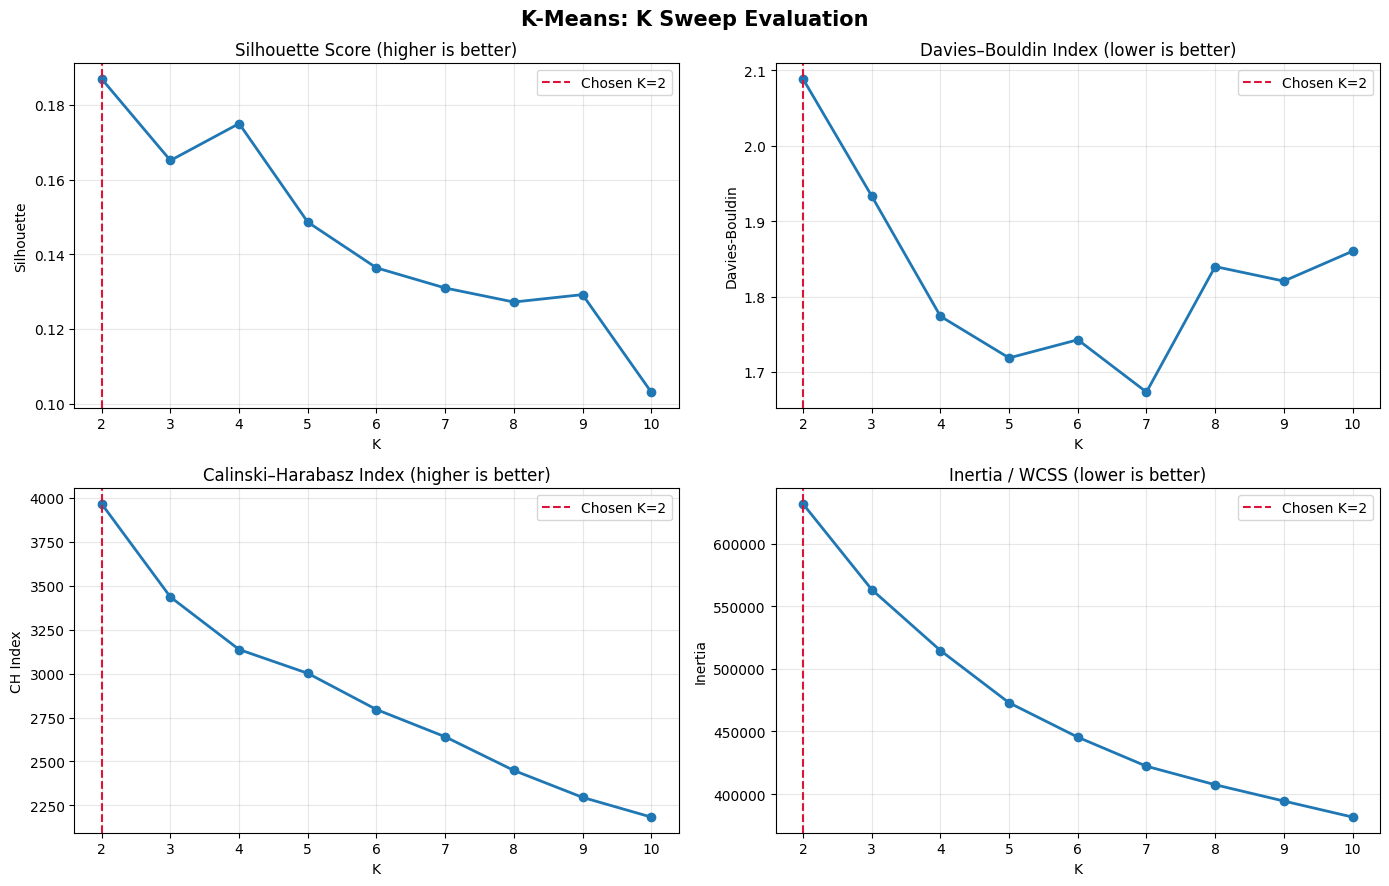

Saved: eval_k_sweep.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("K-Means: K Sweep Evaluation", fontsize=15, fontweight="bold")

plots = [
    (axes[0, 0], sil_scores, "Silhouette", "Silhouette Score (higher is better)"),
    (axes[0, 1], db_scores, "Davies-Bouldin", "Davies–Bouldin Index (lower is better)"),
    (axes[1, 0], ch_scores, "CH Index", "Calinski–Harabasz Index (higher is better)"),
    (axes[1, 1], inertias, "Inertia", "Inertia / WCSS (lower is better)"),
]

for ax, scores, ylabel, title in plots:
    ax.plot(k_values, scores, marker="o", linewidth=2)
    ax.axvline(CHOSEN_K, color="crimson", linestyle="--", label=f"Chosen K={CHOSEN_K}")
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_k_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eval_k_sweep.png")

## 4) Huấn luyện K-Means

K-Means là baseline chính cho bài toán này. Sau khi gán cluster, mình sẽ:
- profile cụm bằng thống kê thực tế
- đặt tên nhóm theo hành vi / genre nổi bật
- tạo trực quan hóa để giải thích kết quả

In [25]:
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=20)
labels = kmeans.fit_predict(X_model_df)
df_clean["cluster_id"] = labels

print(f"Training K-Means with K={CHOSEN_K} on {len(df_clean):,} users\n")
cluster_counts = pd.Series(labels).value_counts().sort_index()

for k, n in cluster_counts.items():
    print(f"Cluster {k}: {n:,} users ({n/len(labels)*100:.1f}%)")

Training K-Means with K=2 on 322,397 users

Cluster 0: 127,345 users (39.5%)
Cluster 1: 195,052 users (60.5%)


## 5) Cluster profiling và đặt tên Taste Tribes

Tên cluster được tạo từ 2 tín hiệu:

1. **Mức độ hoạt động**: dựa trên các magnitude features
2. **Sở thích nổi bật**: dựa trên chênh lệch so với trung bình toàn bộ tập

Nếu một cluster có hoạt động thấp rõ rệt thì gán nhãn **Ít Hoạt Động**.  
Nếu đa số genre đều nằm trên mức trung bình thì gán nhãn **Đa Thể Loại**.  
Các cluster còn lại sẽ được đặt theo top 2 genre nổi bật nhất.

In [26]:
pretty_name = {
    "action": "Hành Động", "adventure": "Phiêu Lưu", "animation": "Hoạt Hình",
    "children": "Thiếu Nhi", "comedy": "Hài", "crime": "Tội Phạm",
    "drama": "Chính Kịch", "documentary": "Tài Liệu", "fantasy": "Giả Tưởng",
    "film_noir": "Noir", "horror": "Kinh Dị", "imax": "IMAX",
    "musical": "Ca Nhạc", "mystery": "Bí Ẩn", "romance": "Tình Cảm",
    "sci_fi": "Khoa Học Viễn Tưởng", "thriller": "Giật Gân",
    "war": "Chiến Tranh", "western": "Viễn Tây",
}

cluster_genre_means = df_clean.groupby("cluster_id")[genre_cols].mean()
overall_genre_mean = df_clean[genre_cols].mean()
distinctiveness = cluster_genre_means.subtract(overall_genre_mean, axis=1)

if magnitude_cols:
    cluster_activity = df_clean.groupby("cluster_id")[magnitude_cols].median().mean(axis=1)
    cluster_activity_z = (cluster_activity - cluster_activity.mean()) / (cluster_activity.std(ddof=0) + 1e-9)
else:
    cluster_activity_z = pd.Series(0.0, index=cluster_genre_means.index)

used_pairs = set()
tribe_names = {}
cluster_notes = []

def humanize_genre(raw_key: str) -> str:
    return pretty_name.get(raw_key, raw_key.replace("_", " ").title())

for k in range(CHOSEN_K):
    ranked = distinctiveness.loc[k].sort_values(ascending=False)
    n_positive = int((ranked > 0).sum())
    total_genres = int(len(ranked))
    size_k = int((df_clean["cluster_id"] == k).sum())
    act_z = float(cluster_activity_z.loc[k]) if k in cluster_activity_z.index else 0.0

    if act_z <= -0.5:
        tribe_names[k] = "Ít Hoạt Động"
        note = f"activity_z={act_z:+.2f}, size={size_k}"
    elif n_positive >= total_genres * 0.8:
        tribe_names[k] = "Đa Thể Loại"
        note = f"{n_positive}/{total_genres} genre features above average"
    else:
        top_keys = [g.replace("genre_pref__", "") for g in ranked.head(5).index]
        chosen = None

        for i in range(len(top_keys)):
            for j in range(i + 1, len(top_keys)):
                pair = tuple(sorted([top_keys[i], top_keys[j]]))
                if pair not in used_pairs:
                    chosen = pair
                    used_pairs.add(pair)
                    break
            if chosen:
                break

        if chosen is None:
            chosen = (top_keys[0], top_keys[1])

        g1 = humanize_genre(chosen[0])
        g2 = humanize_genre(chosen[1])
        tribe_names[k] = f"{g1}–{g2}"
        note = f"top={chosen[0]}, {chosen[1]}"

    cluster_notes.append({
        "cluster_id": k,
        "size": size_k,
        "activity_z": round(act_z, 3),
        "name": tribe_names[k],
        "note": note,
    })

df_clean["tribe_name"] = df_clean["cluster_id"].map(tribe_names)

profile_df = pd.DataFrame(cluster_notes).sort_values("cluster_id")
display(profile_df)

print("\nAssigned cluster names:")
for _, row in profile_df.iterrows():
    print(f"Cluster {int(row['cluster_id'])}: {row['name']}  |  {row['note']}")

,cluster_id,size,activity_z,name,note
0,0,127345,-1.0,Ít Hoạt Động,"activity_z=-1.00, size=127345"
1,1,195052,1.0,Đa Thể Loại,19/19 genre features above average



Assigned cluster names:
Cluster 0: Ít Hoạt Động  |  activity_z=-1.00, size=127345
Cluster 1: Đa Thể Loại  |  19/19 genre features above average


In [27]:
axis_labels = [c.replace("genre_pref__", "").replace("_", " ").title() for c in genre_cols]
colors = px.colors.qualitative.Bold

all_vals = cluster_genre_means.values.flatten()
r_max = float(np.nanmax(all_vals)) * 1.15 if np.isfinite(all_vals).any() else 1.0

fig = go.Figure()
for k in range(CHOSEN_K):
    vals = cluster_genre_means.loc[k].tolist()
    vals = vals + [vals[0]]
    theta = axis_labels + [axis_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals,
        theta=theta,
        fill="toself",
        name=f"Cluster {k}: {tribe_names[k]}",
        line_color=colors[k % len(colors)],
    ))

fig.update_layout(
    title=f"Genre Profiles — Taste Tribes (K={CHOSEN_K})",
    polar=dict(
        radialaxis=dict(visible=True, range=[0, r_max]),
    ),
    height=560,
    showlegend=True,
    template="plotly_dark",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(family="Inter, sans-serif", color="white"),
)

fig.write_html(os.path.join(FIGURES_OUT, "genre_radar.html"))
fig.show()
print("Saved: genre_radar.html")

Saved: genre_radar.html


## 6) t-SNE và PCA

Hai biểu đồ này chỉ dùng để **giải thích trực quan**, không phải để đánh giá mô hình.

In [28]:
TSNE_SAMPLE = min(10000, len(X_model_df))
idx_tsne = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), TSNE_SAMPLE, replace=False)

X_tsne_in = X_model_df.iloc[idx_tsne].values
y_tsne = np.array([tribe_names[l] for l in labels])[idx_tsne]

print(f"Running t-SNE on {TSNE_SAMPLE:,} samples...")
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=min(30, max(5, TSNE_SAMPLE // 500)),
    init="pca",
    learning_rate="auto",
    max_iter=750,
)
X_2d = tsne.fit_transform(X_tsne_in)

df_tsne = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], "Taste Tribe": y_tsne})
df_tsne.to_csv(os.path.join(FIGURES_OUT, "tsne_sample_data.csv"), index=False)

fig = px.scatter(
    df_tsne, x="x", y="y", color="Taste Tribe",
    title=f"t-SNE 2D: Taste Tribes (K={CHOSEN_K}, n={TSNE_SAMPLE:,})",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    template="plotly_dark",
    width=800, height=600,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title=""),
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title=""),
)

fig.write_html(os.path.join(FIGURES_OUT, "cluster_scatter_tsne.html"))
fig.show()
print("Saved: cluster_scatter_tsne.html")

Running t-SNE on 10,000 samples...


Saved: cluster_scatter_tsne.html


In [29]:
PCA_SAMPLE = min(20000, len(X_model_df))
idx_pca = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), PCA_SAMPLE, replace=False)

X_pca_in = X_model_df.iloc[idx_pca].values
y_pca = np.array([tribe_names[l] for l in labels])[idx_pca]

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca.fit_transform(X_pca_in)

print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

df_pca = pd.DataFrame({
    "PC1": X_3d[:, 0],
    "PC2": X_3d[:, 1],
    "PC3": X_3d[:, 2],
    "Taste Tribe": y_pca
})

fig = px.scatter_3d(
    df_pca, x="PC1", y="PC2", z="PC3", color="Taste Tribe",
    title=f"PCA 3D: Taste Tribes (K={CHOSEN_K})",
    opacity=0.55,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    template="plotly_dark",
    width=900, height=650,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
)
fig.write_html(os.path.join(FIGURES_OUT, "cluster_scatter_pca_3d.html"))
fig.show()
print("Saved: cluster_scatter_pca_3d.html")

PCA explained variance ratio: [0.256 0.186 0.099]
Total variance explained: 54.2%


Saved: cluster_scatter_pca_3d.html


## 7) Đánh giá định lượng cho K-Means

Ngoài việc chọn K, mình đánh giá:
- Silhouette plot
- Cluster size distribution
- Davies–Bouldin / Calinski–Harabasz / Inertia

In [30]:
# Align metrics on a sample for computational efficiency
EVAL_SAMPLE_SIZE = min(15000, len(X_model_df))
idx_eval = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), EVAL_SAMPLE_SIZE, replace=False)

X_eval = X_model_df.iloc[idx_eval].values
y_eval = labels[idx_eval]

sil = silhouette_score(X_eval, y_eval)
db = davies_bouldin_score(X_eval, y_eval)
ch = calinski_harabasz_score(X_eval, y_eval)
inertia = float(kmeans.inertia_)

print("=" * 60)
print(f"Chosen K               : {CHOSEN_K}")
print(f"Evaluation sample size : {EVAL_SAMPLE_SIZE:,}")
print(f"Silhouette Score       : {sil:.4f}")
print(f"Davies-Bouldin Index   : {db:.4f}")
print(f"Calinski-Harabasz Index: {ch:.2f}")
print(f"Inertia (WCSS)         : {inertia:.2f}")
print("=" * 60)

Chosen K               : 2
Evaluation sample size : 15,000
Silhouette Score       : 0.1847
Davies-Bouldin Index   : 2.0977
Calinski-Harabasz Index: 2954.51
Inertia (WCSS)         : 10220657.00


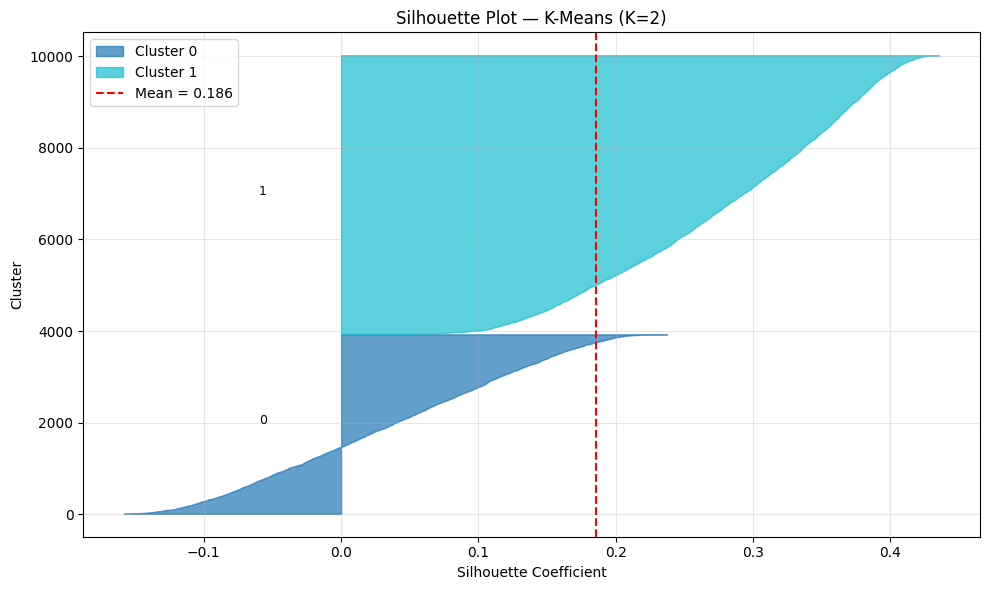

Saved: eval_silhouette_plot.png


In [31]:
sample_sil_size = min(10000, len(X_model_df))
idx_sil = np.random.RandomState(RANDOM_STATE).choice(len(X_model_df), sample_sil_size, replace=False)
X_sil = X_model_df.iloc[idx_sil].values
y_sil = labels[idx_sil]

sample_sil = silhouette_samples(X_sil, y_sil)
cmap = plt.cm.get_cmap("tab10", CHOSEN_K)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i, k in enumerate(np.unique(y_sil)):
    sil_k = np.sort(sample_sil[y_sil == k])
    y_upper = y_lower + len(sil_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k, alpha=0.7, color=cmap(i), label=f"Cluster {k}")
    ax.text(-0.06, y_lower + 0.5 * len(sil_k), str(k), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=float(np.mean(sample_sil)), color="red", linestyle="--", label=f"Mean = {np.mean(sample_sil):.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — K-Means (K={CHOSEN_K})")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_silhouette_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eval_silhouette_plot.png")

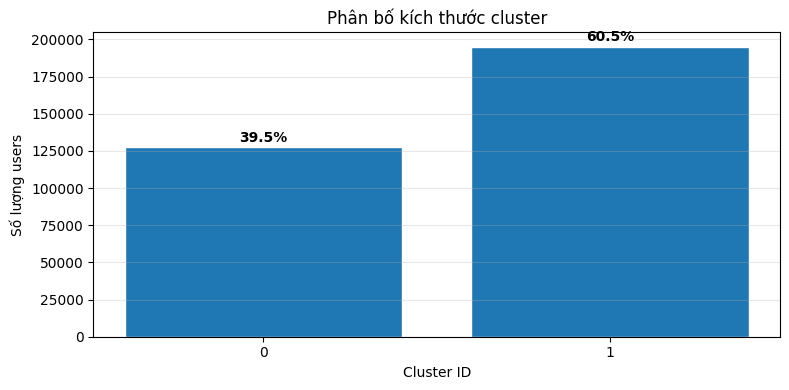

,n_users,pct
0,127345,39.5
1,195052,60.5


In [32]:
cluster_counts = pd.Series(labels).value_counts().sort_index()
cluster_pct = (cluster_counts / cluster_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values, edgecolor="white")
for bar, pct in zip(bars, cluster_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cluster_counts.values) * 0.01,
            f"{pct}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Cluster ID")
ax.set_ylabel("Số lượng users")
ax.set_title("Phân bố kích thước cluster")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, "eval_cluster_sizes.png"), dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"n_users": cluster_counts, "pct": cluster_pct}))

## 8) So sánh với GMM

GMM là mô hình mềm hơn K-Means vì nó học theo phân bố xác suất và covariance của từng cụm.  
Trong notebook này, mình cho GMM chạy trên cùng không gian đặc trưng đã được cân bằng để so sánh công bằng.

In [33]:
gmm = GaussianMixture(
    n_components=CHOSEN_K,
    covariance_type="full",
    random_state=RANDOM_STATE,
    max_iter=300,
    n_init=2,
)
gmm_labels = gmm.fit_predict(X_model_df.values)
df_clean["gmm_cluster"] = gmm_labels
df_clean["gmm_confidence"] = gmm.predict_proba(X_model_df.values).max(axis=1)

# Evaluate GMM on the same sample used for K-Means
gmm_sil = silhouette_score(X_eval, gmm_labels[idx_eval])
gmm_db = davies_bouldin_score(X_eval, gmm_labels[idx_eval])
gmm_ch = calinski_harabasz_score(X_eval, gmm_labels[idx_eval])
gmm_bic = float(gmm.bic(X_model_df.values))
gmm_aic = float(gmm.aic(X_model_df.values))

print("GMM metrics")
print(f"Silhouette       : {gmm_sil:.4f}")
print(f"Davies-Bouldin   : {gmm_db:.4f}")
print(f"Calinski-Harabasz: {gmm_ch:.2f}")
print(f"BIC              : {gmm_bic:.2f}")
print(f"AIC              : {gmm_aic:.2f}")

# GMM naming
gmm_genre_means = df_clean.groupby("gmm_cluster")[genre_cols].mean()
gmm_distinct = gmm_genre_means.subtract(overall_genre_mean, axis=1)

if magnitude_cols:
    gmm_activity = df_clean.groupby("gmm_cluster")[magnitude_cols].median().mean(axis=1)
    gmm_activity_z = (gmm_activity - gmm_activity.mean()) / (gmm_activity.std(ddof=0) + 1e-9)
else:
    gmm_activity_z = pd.Series(0.0, index=gmm_genre_means.index)

gmm_tribe_names = {}
used_pairs_gmm = set()

for k in range(CHOSEN_K):
    ranked = gmm_distinct.loc[k].sort_values(ascending=False)
    n_positive = int((ranked > 0).sum())
    total_genres = int(len(ranked))
    act_z = float(gmm_activity_z.loc[k]) if k in gmm_activity_z.index else 0.0

    if act_z <= -0.5:
        gmm_tribe_names[k] = "Ít Hoạt Động"
        continue
    if n_positive >= total_genres * 0.8:
        gmm_tribe_names[k] = "Đa Thể Loại"
        continue

    top_keys = [g.replace("genre_pref__", "") for g in ranked.head(5).index]
    chosen = None
    for i in range(len(top_keys)):
        for j in range(i + 1, len(top_keys)):
            pair = tuple(sorted([top_keys[i], top_keys[j]]))
            if pair not in used_pairs_gmm:
                chosen = pair
                used_pairs_gmm.add(pair)
                break
        if chosen:
            break

    if chosen is None:
        chosen = (top_keys[0], top_keys[1])

    gmm_tribe_names[k] = f"{humanize_genre(chosen[0])}–{humanize_genre(chosen[1])}"

df_clean["gmm_tribe_name"] = df_clean["gmm_cluster"].map(gmm_tribe_names)

print("\nGMM cluster names:")
for k, name in gmm_tribe_names.items():
    n = int((df_clean["gmm_cluster"] == k).sum())
    print(f"GMM Cluster {k}: {n:,} users → {name}")

GMM metrics
Silhouette       : 0.1538
Davies-Bouldin   : 2.3227
Calinski-Harabasz: 2437.29
BIC              : 15740008.11
AIC              : 15731942.04

GMM cluster names:
GMM Cluster 0: 181,474 users → Đa Thể Loại
GMM Cluster 1: 140,923 users → Ít Hoạt Động


In [34]:
# Boxplot comparison: K-Means vs GMM on raw n_ratings (log scale)
if "n_ratings" in df_clean.columns:
    df_clean["real_n_ratings"] = np.expm1(df_clean["n_ratings"])
else:
    df_clean["real_n_ratings"] = np.nan

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("K-Means clusters", "GMM clusters")
)

for tribe in df_clean["tribe_name"].dropna().unique():
    subset = df_clean[df_clean["tribe_name"] == tribe]
    fig.add_trace(go.Box(y=subset["real_n_ratings"], name=tribe, boxpoints=False), row=1, col=1)

for tribe in df_clean["gmm_tribe_name"].dropna().unique():
    subset = df_clean[df_clean["gmm_tribe_name"] == tribe]
    fig.add_trace(go.Box(y=subset["real_n_ratings"], name=tribe, boxpoints=False), row=1, col=2)

fig.update_layout(
    template="plotly_dark",
    height=560,
    width=1000,
    title_text="So sánh phân bố số phim đã xem giữa K-Means và GMM",
    yaxis=dict(type="log", title="Tổng số phim đã xem (log scale)"),
    yaxis2=dict(type="log"),
    showlegend=False,
)

fig.write_html(os.path.join(FIGURES_OUT, "compare_kmeans_gmm_boxplot.html"))
fig.show()
print("Saved: compare_kmeans_gmm_boxplot.html")

Saved: compare_kmeans_gmm_boxplot.html


In [35]:
# Sankey: chuyển dịch user từ K-Means sang GMM
kmeans_names = [f"K-Means: {name}" for name in pd.Series(df_clean["tribe_name"]).dropna().unique()]
gmm_names = [f"GMM: {name}" for name in pd.Series(df_clean["gmm_tribe_name"]).dropna().unique()]
all_nodes = list(kmeans_names) + list(gmm_names)
node_dict = {name: i for i, name in enumerate(all_nodes)}

source, target, value = [], [], []
flow_counts = df_clean.groupby(["tribe_name", "gmm_tribe_name"]).size().reset_index(name="count")

for _, row in flow_counts.iterrows():
    source.append(node_dict[f"K-Means: {row['tribe_name']}"])
    target.append(node_dict[f"GMM: {row['gmm_tribe_name']}"])
    value.append(int(row["count"]))

node_colors = ["#FF4B4B", "#FFA800", "#00D26A", "#4C78A8", "#F58518", "#54A24B"] * 3

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=18,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors[:len(all_nodes)],
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(200, 200, 250, 0.35)",
    ),
)])

fig_sankey.update_layout(
    title_text="Sankey: Dòng chảy người dùng từ K-Means sang GMM",
    font=dict(size=13, color="white"),
    template="plotly_dark",
    width=1000,
    height=650,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
)

fig_sankey.write_html(os.path.join(FIGURES_OUT, "sankey_kmeans_vs_gmm.html"))
fig_sankey.show()
print("Saved: sankey_kmeans_vs_gmm.html")

same_group = int((df_clean["tribe_name"] == df_clean["gmm_tribe_name"]).sum())
diff_group = len(df_clean) - same_group
print(f"Users kept the same group: {same_group:,} ({same_group / len(df_clean) * 100:.1f}%)")
print(f"Users changed group      : {diff_group:,} ({diff_group / len(df_clean) * 100:.1f}%)")

Saved: sankey_kmeans_vs_gmm.html
Users kept the same group: 282,901 (87.7%)
Users changed group      : 39,496 (12.3%)


## 9) Xuất artifact

Mục tiêu của phần này là để notebook không chỉ “chạy xong” mà còn để lại file đầu ra cho report, demo hoặc app.

In [36]:
from IPython.display import display

# Cluster labels table
labels_df = df_clean[[
    "userId", "cluster_id", "tribe_name",
    "gmm_cluster", "gmm_tribe_name", "gmm_confidence"
]].copy()

labels_df.to_parquet(os.path.join(TABLES_OUT, "cluster_labels_users.parquet"), index=False)
print(f"Saved: cluster_labels_users.parquet ({len(labels_df):,} rows)")

# Cluster profiles JSON
profiles = {}
for k in range(CHOSEN_K):
    mask = df_clean["cluster_id"] == k
    center = dict(zip(model_feature_cols, kmeans.cluster_centers_[k].tolist()))
    top_genres = sorted([(col, center[col]) for col in genre_cols], key=lambda x: x[1], reverse=True)[:5]

    profiles[str(k)] = {
        "cluster_id": int(k),
        "name": tribe_names[k],
        "n_users": int(mask.sum()),
        "activity_z": float(cluster_activity_z.loc[k]) if k in cluster_activity_z.index else 0.0,
        "centroid": center,
        "top_genres": [g[0] for g in top_genres],
    }

with open(os.path.join(REPORTS_OUT, "cluster_profiles.json"), "w", encoding="utf-8") as f:
    json.dump(profiles, f, indent=4, ensure_ascii=False)
print("Saved: cluster_profiles.json")

# Markdown cluster cards
cards_lines = ["# Cluster Profiles", ""]
for k, p in profiles.items():
    cards_lines.append(f"## Cluster {k} — {p['name']} ({p['n_users']:,} users)")
    cards_lines.append(f"**Top genres:** {', '.join(p['top_genres'])}")
    cards_lines.append("")

with open(os.path.join(REPORTS_OUT, "cluster_cards.md"), "w", encoding="utf-8") as f:
  f.write("\n".join(cards_lines))
print("Saved: cluster_cards.md")

# Evaluation metrics
eval_metrics = {
    "k": int(CHOSEN_K),
    "silhouette_score": round(float(sil), 6),
    "davies_bouldin_index": round(float(db), 6),
    "calinski_harabasz": round(float(ch), 4),
    "inertia": round(float(inertia), 4),
    "sample_size": int(len(X_model_df)),
    "k_weight_formula": f"sqrt({len(genre_cols)}/{len(magnitude_cols)})" if magnitude_cols else "1.0",
    "gmm": {
        "silhouette_score": round(float(gmm_sil), 6),
        "davies_bouldin_index": round(float(gmm_db), 6),
        "calinski_harabasz": round(float(gmm_ch), 4),
        "bic": round(float(gmm_bic), 4),
        "aic": round(float(gmm_aic), 4),
    },
}

with open(os.path.join(REPORTS_OUT, "eval_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(eval_metrics, f, indent=4, ensure_ascii=False)
print("Saved: eval_metrics.json")

# Run manifest
manifest = {
    "story": "Story A: Taste Tribes",
    "timestamp": datetime.datetime.now().isoformat(),
    "notebook": os.path.basename(out_path),
    "inputs": ["user_features_train.parquet", "dim_movies_clean.parquet", "interactions_train.parquet"],
    "method": "Balanced KMeans + GMM comparison",
    "parameters": {
        "k": int(CHOSEN_K),
        "random_state": RANDOM_STATE,
        "sample_size": int(SAMPLE_SIZE),
        "mag_weight": float(MAG_WEIGHT),
    },
    "metrics": {k: v for k, v in eval_metrics.items() if k != "gmm"},
    "outputs": [
        "tables/cluster_labels_users.parquet",
        "reports/cluster_profiles.json",
        "reports/cluster_cards.md",
        "reports/eval_metrics.json",
        "figures/eval_k_sweep.png",
        "figures/genre_radar.html",
        "figures/cluster_scatter_tsne.html",
        "figures/cluster_scatter_pca_3d.html",
        "figures/eval_silhouette_plot.png",
        "figures/eval_cluster_sizes.png",
        "figures/compare_kmeans_gmm_boxplot.html",
        "figures/sankey_kmeans_vs_gmm.html",
    ],
}
with open(os.path.join(REPORTS_OUT, "run_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4, ensure_ascii=False)
print("Saved: run_manifest.json")

print("\n✅ All artifacts exported to:", STORY_DIR)

Saved: cluster_labels_users.parquet (322,397 rows)
Saved: cluster_profiles.json
Saved: cluster_cards.md
Saved: eval_metrics.json


NameError: name 'out_path' is not defined